# Netflix Content Analytics — Exploratory Data Analysis

This notebook explores the Netflix titles catalog: what kind of content Netflix has added over time, where it comes from, how it's rated, and how long it runs.

**Dataset**: Kaggle ["Netflix Movies and TV Shows"](https://www.kaggle.com/datasets/shivamb/netflix-shows) (`netflix_titles.csv`). If the CSV isn't present in `data/`, a synthetic sample dataset is generated automatically so this notebook always runs end-to-end — see `src/generate_sample_data.py`.

**Sections**
1. Load & clean the data
2. Missing values
3. Content type mix (Movies vs. TV Shows)
4. Growth over time
5. Countries & genres
6. Ratings & duration
7. Directors
8. Key takeaways

In [15]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import analysis
from src.data_loader import load_clean, load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Load & clean the data

In [16]:
raw = load_raw()
print(raw.shape)
raw.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
df = load_clean()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          8807 non-null   str           
 4   cast              8807 non-null   str           
 5   country           8807 non-null   str           
 6   date_added        8797 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   str           
 9   duration          8804 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  year_added        8797 non-null   float64       
 13  month_added       8797 non-null   str           
 14  country_list      8807 non-null   o

## 2. Missing values

In [18]:
missing = raw.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1).to_frame("pct_missing")

,pct_missing
director,29.9
country,9.4
cast,9.4
date_added,0.1
rating,0.0
duration,0.0


`director`, `cast`, and `country` are the columns most likely to have gaps. These are filled with `"Unknown"` during cleaning (see `src/data_loader.clean`) rather than dropped, so we don't lose rows for downstream counts that don't depend on the missing field.

## 3. Content type mix

,type,count
0,Movie,6131
1,TV Show,2676


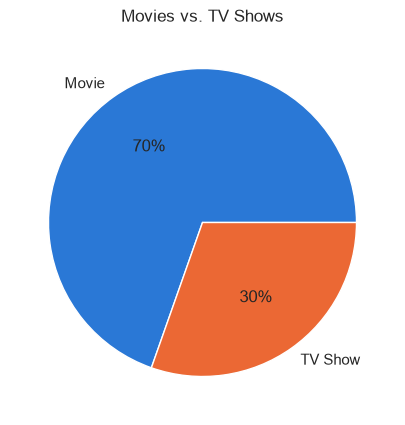

In [29]:
type_counts = analysis.content_type_counts(df)
display(type_counts)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(type_counts["count"], labels=type_counts["type"], autopct="%1.0f%%",
       colors=["#2a78d6", "#eb6834"])
ax.set_title("Movies vs. TV Shows")
plt.show()

### Insight

Movies make up **69.6%** of the Netflix catalog, compared with **30.4%** for TV Shows. This indicates that the dataset contains more movie titles than TV series, with movies representing more than twice the number of TV Shows.

## 4. Growth over time

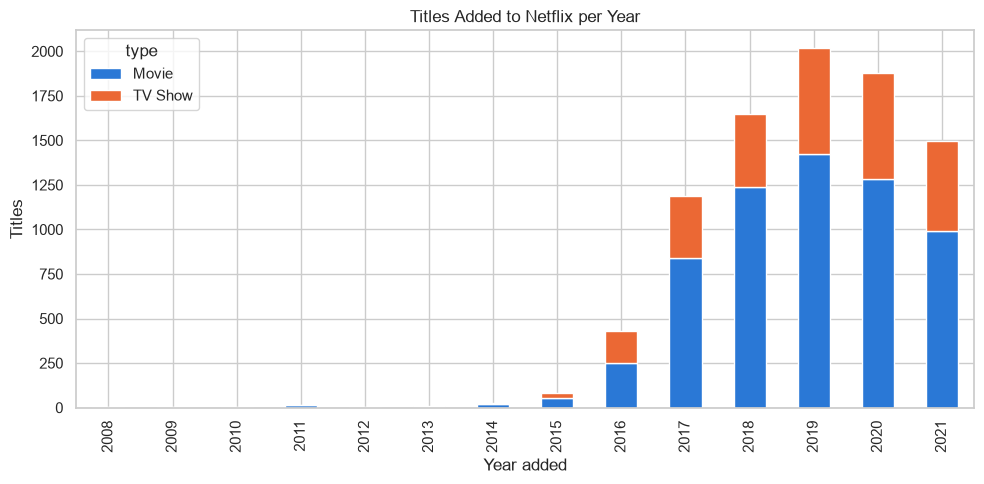

In [20]:
added = analysis.titles_added_per_year(df)
pivot = added.pivot(index="year_added", columns="type", values="count").fillna(0)

ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5),
                 color=["#2a78d6", "#eb6834"])
ax.set_title("Titles Added to Netflix per Year")
ax.set_xlabel("Year added")
ax.set_ylabel("Titles")
plt.tight_layout()
plt.show()

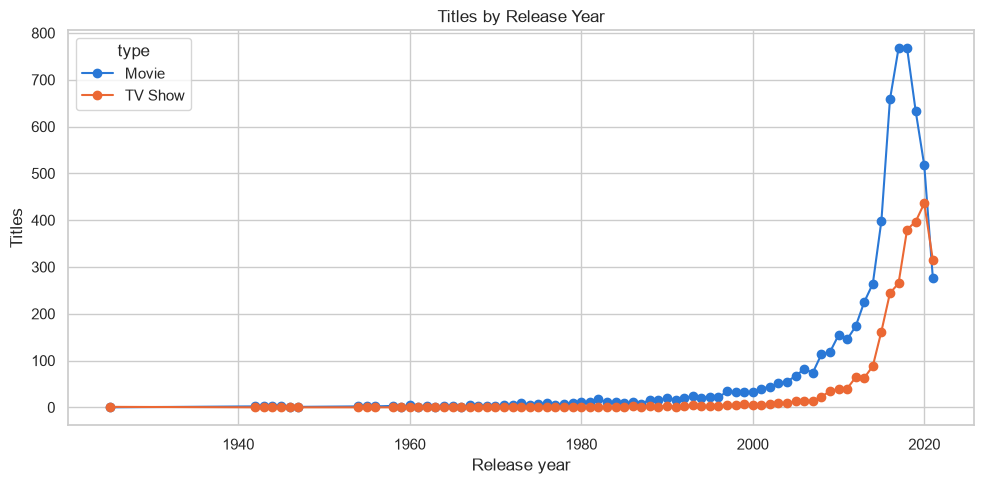

In [21]:
trend = analysis.release_year_trend(df)
pivot2 = trend.pivot(index="release_year", columns="type", values="count").fillna(0)

ax = pivot2.plot(figsize=(10, 5), marker="o", color=["#2a78d6", "#eb6834"])
ax.set_title("Titles by Release Year")
ax.set_xlabel("Release year")
ax.set_ylabel("Titles")
plt.tight_layout()
plt.show()

## 5. Countries & genres

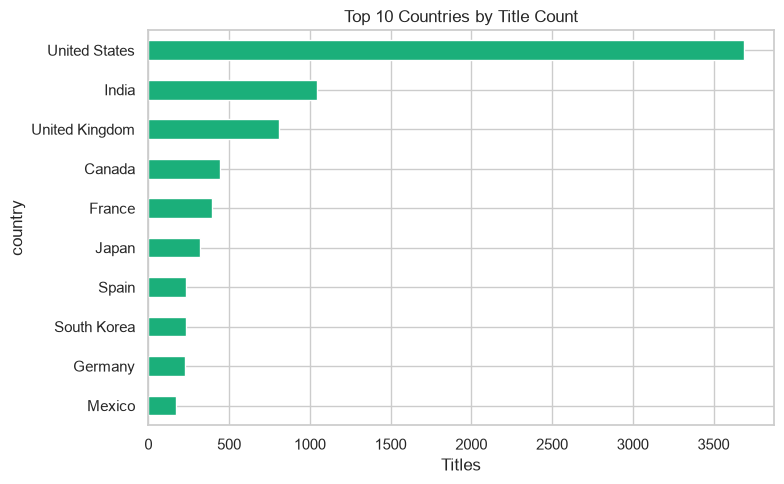

In [22]:
countries = analysis.top_countries(df, n=10).sort_values("count")
ax = countries.plot.barh(x="country", y="count", figsize=(8, 5), color="#1baf7a", legend=False)
ax.set_title("Top 10 Countries by Title Count")
ax.set_xlabel("Titles")
plt.tight_layout()
plt.show()

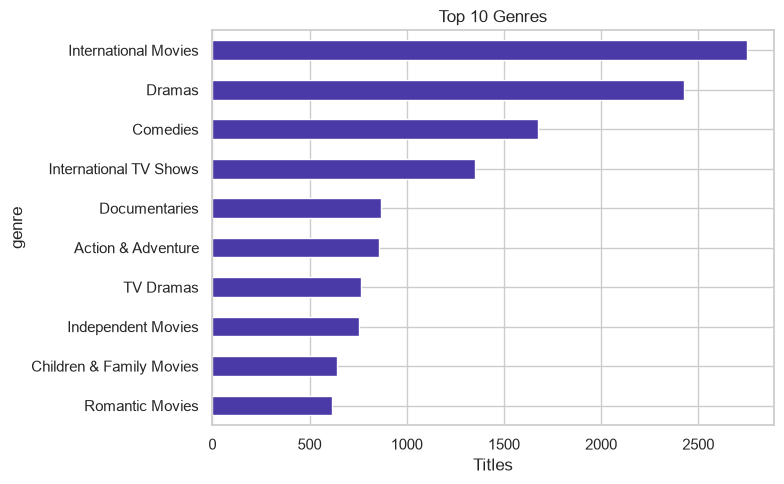

In [23]:
genres = analysis.top_genres(df, n=10).sort_values("count")
ax = genres.plot.barh(x="genre", y="count", figsize=(8, 5), color="#4a3aa7", legend=False)
ax.set_title("Top 10 Genres")
ax.set_xlabel("Titles")
plt.tight_layout()
plt.show()

## 6. Ratings & duration

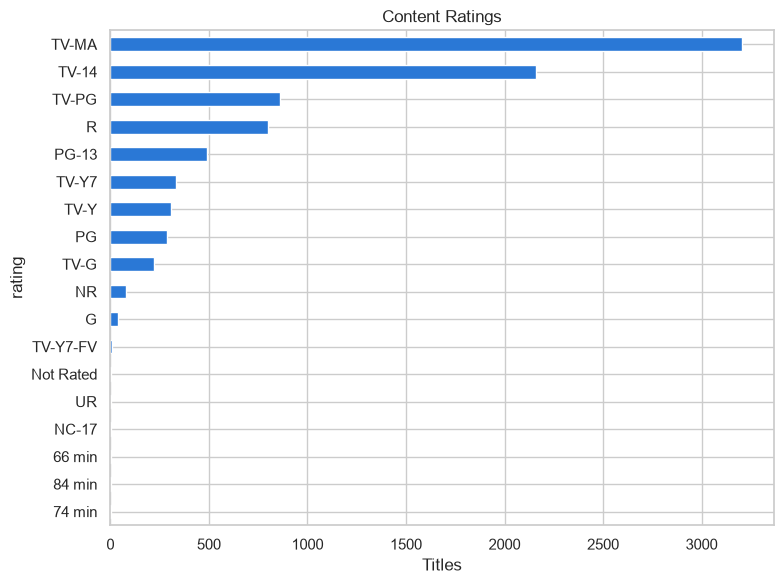

In [24]:
ratings = analysis.rating_distribution(df).sort_values("count")
ax = ratings.plot.barh(x="rating", y="count", figsize=(8, 6), color="#2a78d6", legend=False)
ax.set_title("Content Ratings")
ax.set_xlabel("Titles")
plt.tight_layout()
plt.show()

In [25]:
analysis.duration_summary(df).round(1)

,type,mean,median,min,max
0,Movie (minutes),99.6,98.0,3.0,312.0
1,TV Show (seasons),1.8,1.0,1.0,17.0


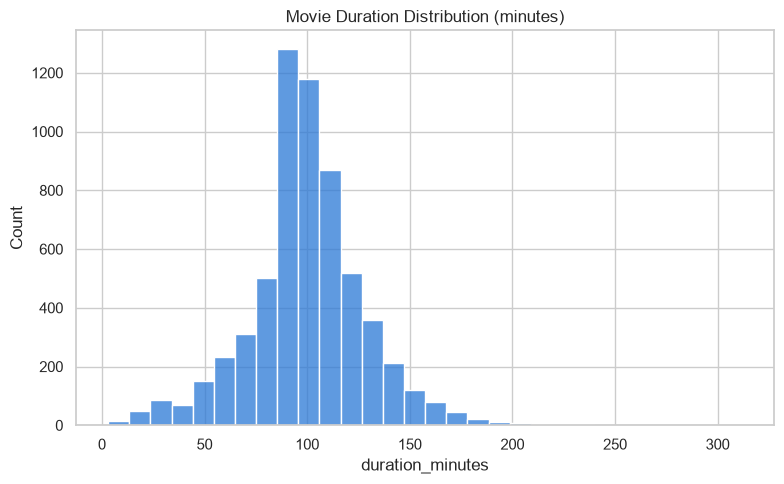

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df.loc[df["type"] == "Movie", "duration_minutes"].dropna(), bins=30,
             color="#2a78d6", ax=ax)
ax.set_title("Movie Duration Distribution (minutes)")
plt.tight_layout()
plt.show()

## 7. Directors

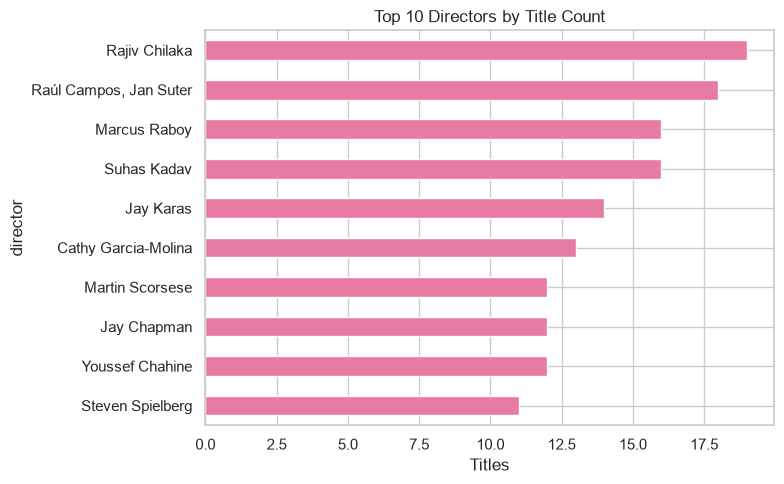

In [27]:
directors = analysis.top_directors(df, n=10).sort_values("count")
ax = directors.plot.barh(x="director", y="count", figsize=(8, 5), color="#e87ba4", legend=False)
ax.set_title("Top 10 Directors by Title Count")
ax.set_xlabel("Titles")
plt.tight_layout()
plt.show()

In [28]:
# Key metrics for the final takeaways

total_titles = len(df)

movie_count = (df["type"] == "Movie").sum()
tv_count = (df["type"] == "TV Show").sum()

movie_pct = movie_count / total_titles * 100
tv_pct = tv_count / total_titles * 100

top_country = analysis.top_countries(df, n=1).iloc[0]

top_genre = analysis.top_genres(df, n=1).iloc[0]

avg_movie_duration = df.loc[
    df["type"] == "Movie", "duration_minutes"
].mean()

median_movie_duration = df.loc[
    df["type"] == "Movie", "duration_minutes"
].median()

print(f"Total titles: {total_titles:,}")
print(f"Movies: {movie_count:,} ({movie_pct:.1f}%)")
print(f"TV Shows: {tv_count:,} ({tv_pct:.1f}%)")
print(f"Top country: {top_country['country']} ({top_country['count']:,} titles)")
print(f"Top genre: {top_genre['genre']} ({top_genre['count']:,} titles)")
print(f"Average movie duration: {avg_movie_duration:.1f} minutes")
print(f"Median movie duration: {median_movie_duration:.1f} minutes")

Total titles: 8,807
Movies: 6,131 (69.6%)
TV Shows: 2,676 (30.4%)
Top country: United States (3,690 titles)
Top genre: International Movies (2,752 titles)
Average movie duration: 99.6 minutes
Median movie duration: 98.0 minutes


## 8. Key takeaways

- **Movies dominate the catalog:** Movies account for **6,131 titles (69.6%)**, while TV Shows account for **2,676 titles (30.4%)**.

- **The United States is the largest represented country:** Titles associated with the United States account for **3,690 titles**, making it the largest country in the dataset.

- **International Movies is the most common genre:** The **International Movies** category contains **2,752 titles**, making it the largest genre category in the catalog.

- **Movie runtimes center around feature-length viewing:** Movies have an average duration of **99.6 minutes** and a median duration of **98 minutes**. The range extends from **3 to 312 minutes**, indicating substantial variation in movie length.

- **TV Shows generally have short season counts:** TV Shows average **1.8 seasons**, with a median of **1 season**. The maximum is **17 seasons**, showing that most titles have relatively few seasons while a smaller number run for many seasons.

- **Metadata completeness varies across fields:** `director` has the highest missing-data rate at **29.9%**, followed by `country` and `cast` at **9.4% each**. This is important when interpreting analyses based on these fields.